# Damped Harmonic Oscillator (DHO)

This notebook focuses exclusively on the `DHO` benchmark from Appendix A.2 of *Hybrid Quantum Physics-informed Neural Network: Towards Efficient Learning of High-speed Flows* (http://arxiv.org/abs/2503.02202).

In [1]:
# from HQPINN.notebook_dho_helpers import *
try:
    from notebook_dho_helpers import *
except ModuleNotFoundError:
    from HQPINN.notebook_dho_helpers import *

## Governing equation

In Appendix A.2, the paper studies the damped harmonic oscillator

$$
m u''(t) + \mu u'(t) + k u(t) = 0,
\qquad t \in (0, 1],
$$
with
$u(0) = 1$, $u'(0) = 0$, $m = 1$, $\mu = 4$, and $k = 400$.


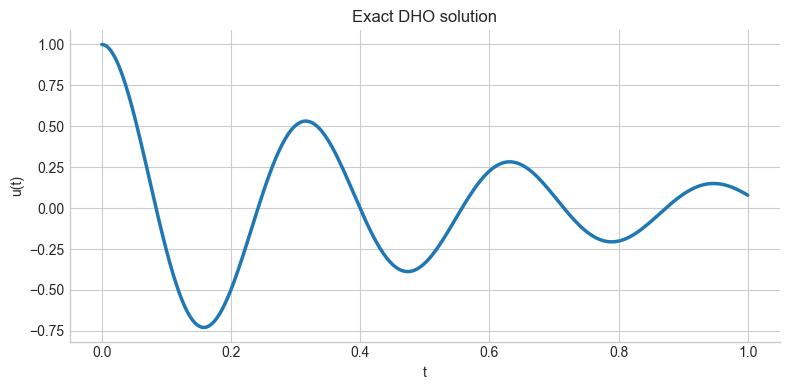

In [2]:
display_exact_dho_solution()


## Models Architecture

Across the paper, every `DHO` model follows the same high-level template: two parallel branches take the same input `t`, and their outputs are fused by a small learned readout. What changes from one variant to another is the type of each branch: classical or quantum.

- `qq-pl-l`: `l` denotes the number of qubits in the PennyLane quantum branch
- `qq-m-p`: `p` denotes the number of photons in the MerLin quantum branch
- `qq-mp`: uses the default Perceval quantum configuration
- `hy-pl-N-L-l`:
    - `N` denotes the number of nodes in the classical branch 
    - `L` denotes the number of layers in the classical branch 
    - `l` the number of qubits in the PennyLane quantum branch
- `hy-m-N-L-p`:
    - `N-L` describes the classical branch 
    - `p` describes the MerLin quantum branch
- `hy-mp-N-L`: 
    - `N-L` describes the classical branch
    - the quantum branch uses the default Perceval configuration.


## DHO Setup

In [3]:
display_dho_setup()

DHO constants
------------------------------------------------------------------------
m=1.0, mu=4.0, k=400.0

Training setup used in this reproduction
------------------------------------------------------------------------
optimizer                : Adam
learning rate            : 0.002
epochs                   : 1800
loss history             : one entry every 100 epochs
time grid                : 200 points on [0, 1]
interior training points : 199 (t=0 handled separately)
loss weights             : lambda1=0.1, lambda2=0.0001
dtype                    : torch.float64


### Variants Compared in This Notebook

| Order | Code | Branch 1 | Branch 2 | Size used in this reproduction |
|---|---|---|---|---|
| 1 | `cc` | classical | classical | `16-2` |
| 2 | `qq-pl` | quantum PennyLane | quantum PennyLane | `3` |
| 3 | `hy-pl` | quantum PennyLane | classical | `16-2-3` |
| 4 | `qq-m` | quantum Merlin | quantum Merlin | `1` |
| 5 | `qq-mp` | quantum Perceval | quantum Perceval | `default` |
| 6 | `hy-m` | quantum Merlin | classical | `16-2-1` |
| 7 | `hy-mp` | quantum Perceval | classical | `16-2` |

## Loss function

$$
\mathcal{L} = \mathcal{L}_{IC,u} + \lambda_1 \mathcal{L}_{IC,u'} + \lambda_2 \mathcal{L}_{PDE},
$$

with

$$
\mathcal{L}_{IC,u} = (u_\theta(0) - 1)^2,
\qquad
\mathcal{L}_{IC,u'} = (u'_\theta(0))^2,
$$

and

$$
\mathcal{L}_{PDE} = \frac{1}{N}\sum_i
\left(m u''_\theta(t_i) + \mu u'_\theta(t_i) + k u_\theta(t_i)\right)^2.
$$

In [4]:
def dho_loss_from_paper(model, t):
    # Make the time grid differentiable so autograd can compute u'(t) and u''(t).
    t = t.clone().detach().requires_grad_(True)

    # Neural network prediction u_theta(t).
    u = model(t)

    # Automatic differentiation gives the first and second derivatives.
    du = derivative(u, t)
    d2u = second_derivative(u, t)

    # Physics residual from the paper: m u'' + mu u' + k u.
    residual = M * d2u + MU * du + K * u

    # Initial conditions are enforced at t = 0.
    t0 = torch.zeros((1, 1), dtype=DTYPE, device=DEVICE).requires_grad_(True)
    u0 = model(t0)
    du0 = derivative(u0, t0)

    loss_ic_u = (u0 - 1.0) ** 2
    loss_ic_du = du0**2
    loss_pde = torch.mean(residual**2)

    return (
        loss_ic_u.squeeze(),
        loss_ic_du.squeeze(),
        loss_pde.squeeze(),
    )


## The Training Loop

Every model follows the exact same logic:
1. build the model;
2. evaluate the three DHO loss terms;
3. assemble the total loss;
4. apply the Adam update;
5. store the history for the learning curve.

In [5]:
def train_one_model(
    spec: dict[str, object],
    *,
    epochs: int = DHO_N_EPOCHS,
    lr: float = DHO_LR,
    log_every: int = DHO_PLOT_EVERY,
) -> dict[str, object]:
    """Train one DHO variant using the same PINN loop for every model."""

    # Fix randomness.
    seed_everything(0)

    # Build the selected model.
    model = build_model(spec)
    model.train()

    # Training inputs.
    t_train = make_time_grid()

    # Optimizer state.
    optimizer = make_optimizer(model, lr=lr)

    # Store a few snapshots of training for the loss curve and summary table.
    # Each entry keeps the epoch, elapsed time, and loss terms.
    history: list[dict[str, float]] = []

    # Start timing.
    start = perf_counter()

    for epoch in range(epochs):
        # Clear gradients from the previous step.
        optimizer.zero_grad()

        # 1) The three terms used in the paper: two initial conditions + one physics residual.
        loss_ic_u, loss_ic_du, loss_pde = dho_loss_from_paper(model, t_train)

        # 2) The total loss combines them with the reproduction weights.
        loss = loss_ic_u + LAMBDA1 * loss_ic_du + LAMBDA2 * loss_pde

        # 3) Backpropagation and parameter update.
        loss.backward()
        optimizer.step()

        # 4) Keep a lightweight history for the learning curve.
        if epoch % log_every == 0 or epoch == epochs - 1:
            history.append(
                {
                    "epoch": epoch,
                    "elapsed_s": perf_counter() - start,
                    "loss": float(loss.item()),
                    "ic_u": float(loss_ic_u.item()),
                    "ic_du": float(loss_ic_du.item()),
                    "pde": float(loss_pde.item()),
                }
            )

    return {
        # Short identifiers reused in headings, legends, and tables.
        "name": spec["name"],
        "paper_label": spec["paper_label"],
        # Branch descriptions 
        "branch_1": spec["branch_1"],
        "branch_2": spec["branch_2"],
        "branches": spec["branches"],
        # Visual and naming metadata for plots and saved artifacts
        "color": spec["color"],
        "case_prefix": spec["case_prefix"],
        # Original architecture specification used to build the model
        "spec": spec,
        "size": spec["size_hint"],
        # Final run statistics used in the comparison
        "params": count_trainable_params(model),
        "elapsed_s": history[-1]["elapsed_s"],
        "final_loss": history[-1]["loss"],
        # Full logged history for the learning curve
        "history": history,
        # Provenance for display: this result comes from the current session
        "source": "run computed in this notebook",
        # No saved run id yet because this notebook path does not write one
        "run_id": None,
        # Keep the trained model in memory for immediate prediction plots
        "model": model,
    }


def run_dho_case(
    spec: dict[str, object],
    *,
    run_training: bool,
    epochs: int = DHO_N_EPOCHS,
) -> dict[str, object]:
    # Either train a fresh run or reload the latest saved one.
    if run_training:
        return train_one_model(spec, epochs=epochs)
    return load_saved_case(spec)

## Trainings

By default, the notebook reloads the **latest saved histories** so that it stays lightweight and immediately readable.

For each model, the notebook now shows both the learning curve and the trajectory `u(t)` against the exact DHO solution.
If you want to rerun training directly from the notebook, set `RUN_TRAINING = True` in the next cell. The most expensive cases are `qq-pl` and then `hy-pl`, so this mode is mainly intended for a longer run.


**Execution mode:** reload the latest saved histories.

### CC

Code     : cc
Branches : classical + classical
Source   : latest saved run (20260403-185410)
Runtime  : 2.74 s | Parameters : 721 | Final loss : 3.6180e-02


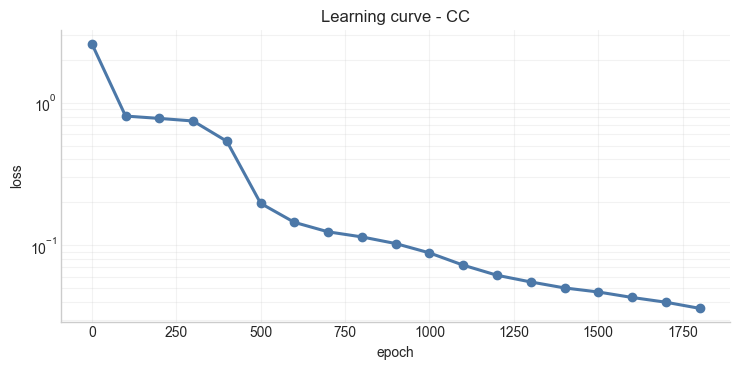

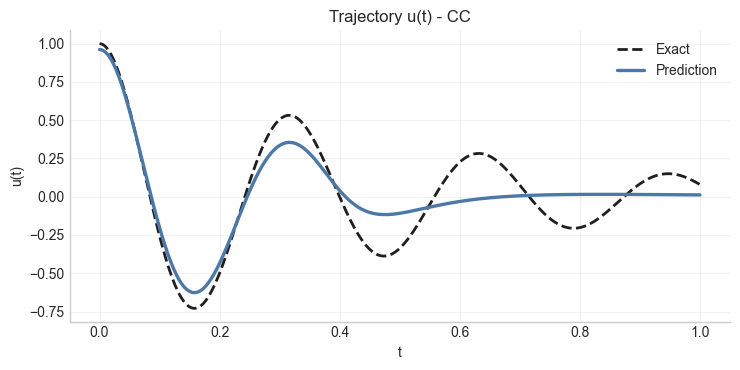

### QQ-PL

Code     : qq-pl
Branches : quantum PennyLane + quantum PennyLane
Source   : latest saved run (20260403-220050)
Runtime  : 2.48 h | Parameters : 57 | Final loss : 5.6532e-04


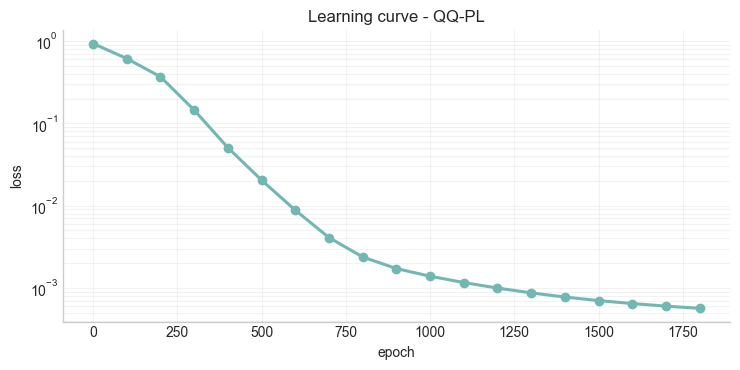

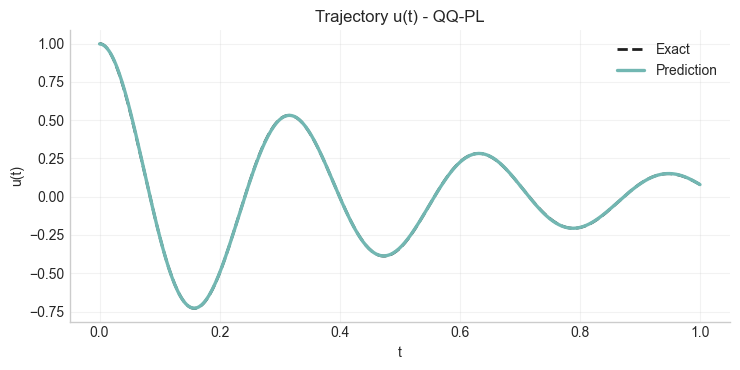

### HY-PL

Code     : hy-pl
Branches : quantum PennyLane + classical
Source   : latest saved run (20260403-204813)
Runtime  : 1.13 h | Parameters : 353 | Final loss : 2.2967e-02


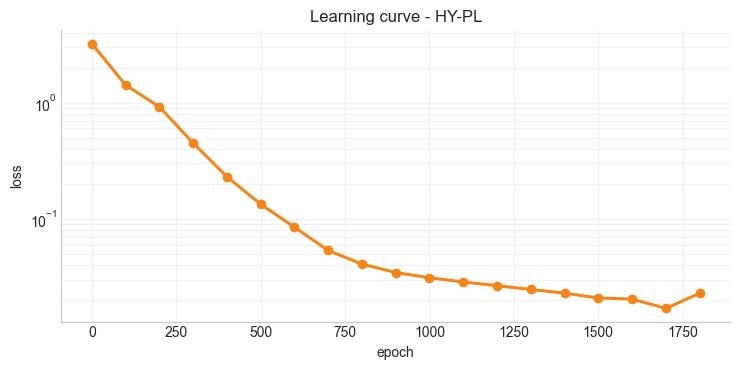

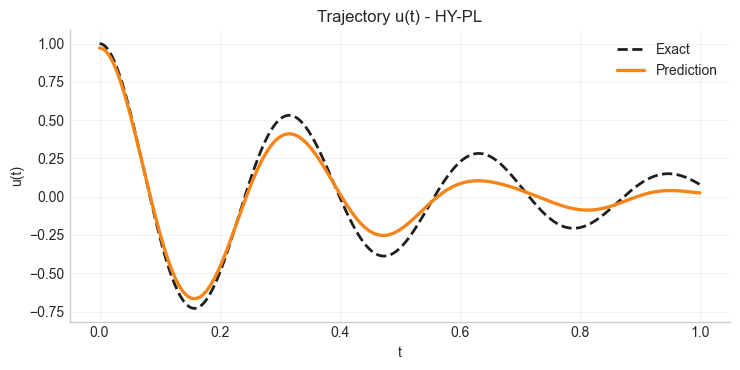

### QQ-M

Code     : qq-m
Branches : quantum Merlin + quantum Merlin
Source   : latest saved run (20260403-215611)
Runtime  : 2.7 min | Parameters : 197 | Final loss : 9.1958e-03


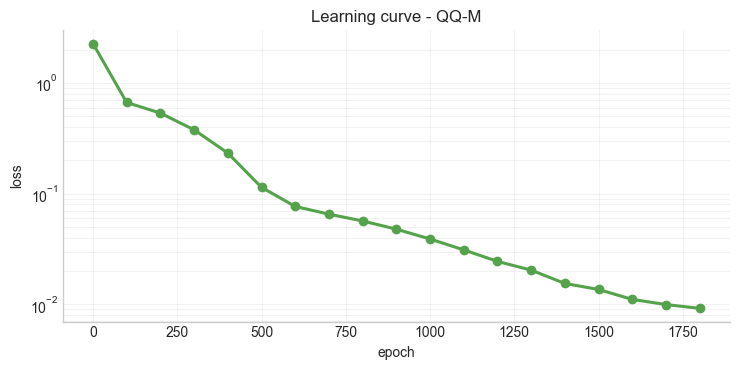

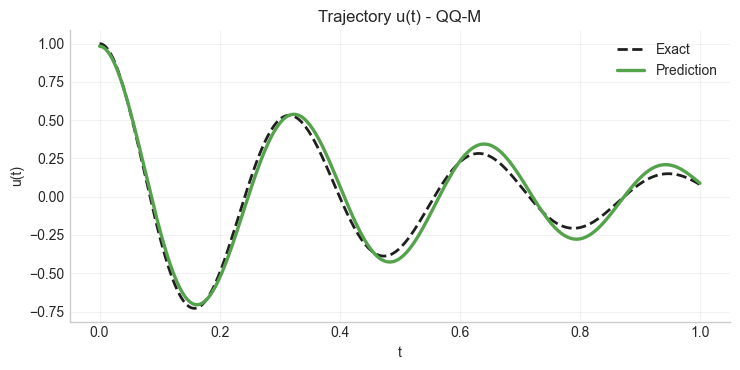

### QQ-MP

Code     : qq-mp
Branches : quantum Perceval + quantum Perceval
Source   : latest saved run (20260403-215855)
Runtime  : 1.8 min | Parameters : 71 | Final loss : 5.9419e-04


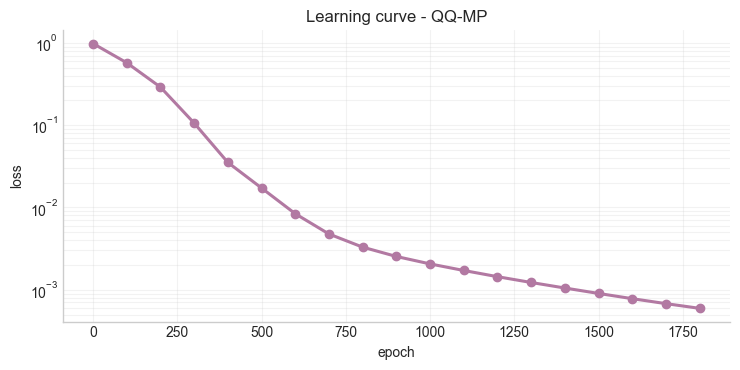

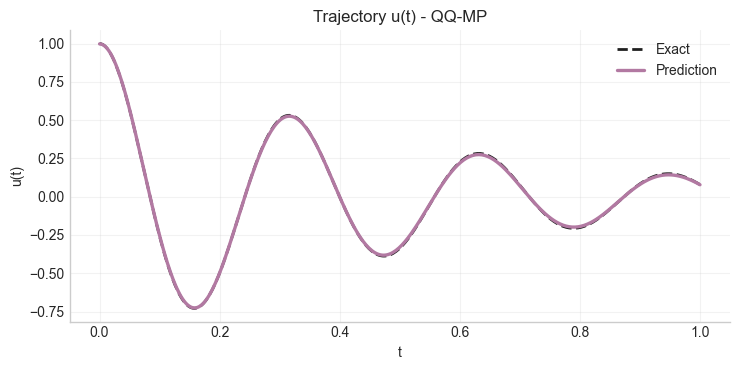

### HY-M

Code     : hy-m
Branches : quantum Merlin + classical
Source   : latest saved run (20260403-185703)
Runtime  : 56.7 min | Parameters : 423 | Final loss : 4.7615e-02


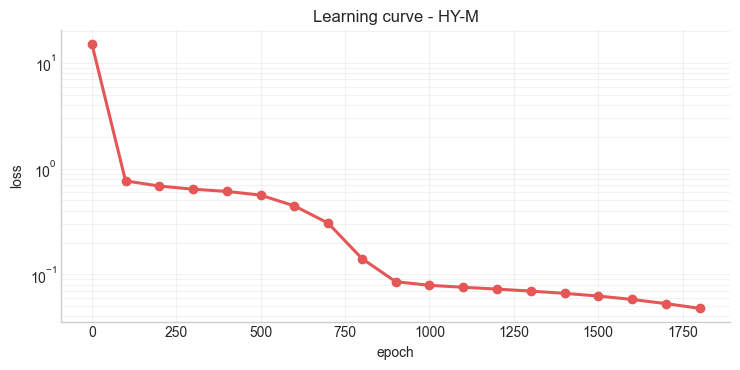

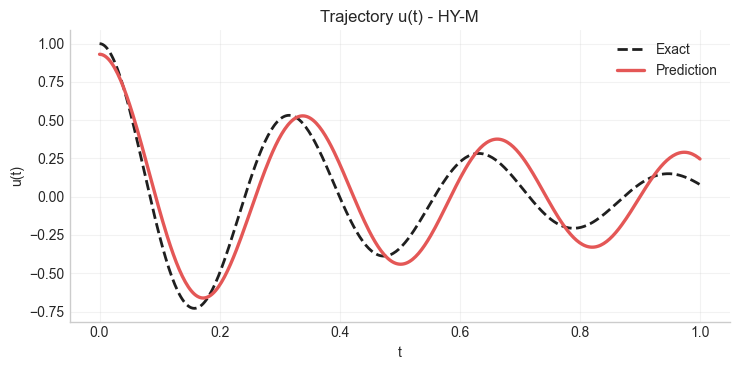

### HY-MP

Code     : hy-mp
Branches : quantum Perceval + classical
Source   : latest saved run (20260403-185415)
Runtime  : 2.8 min | Parameters : 360 | Final loss : 1.1835e-02


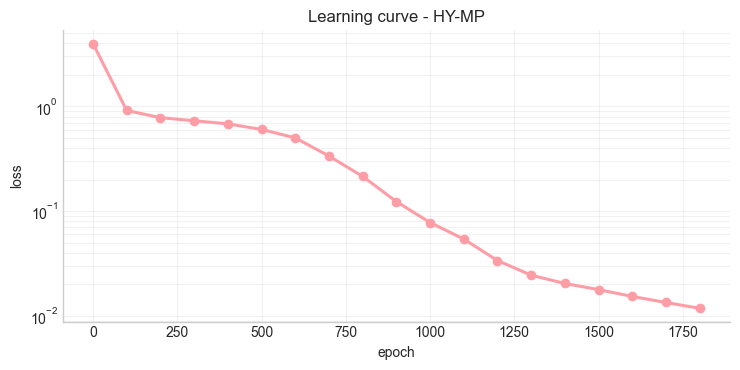

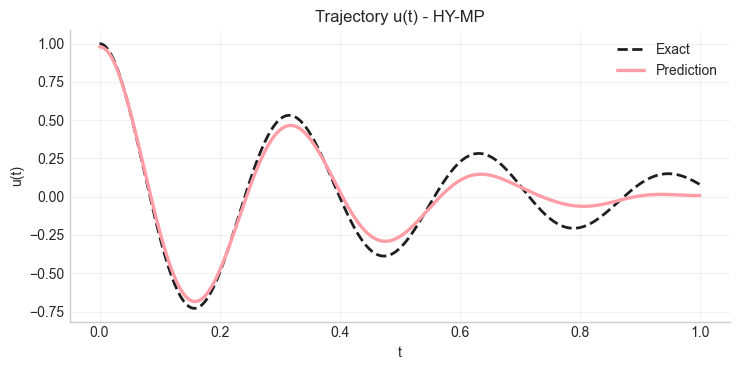

In [6]:
# Choose between training from scratch and reloading saved runs.
RUN_TRAINING = False
# Number of epochs used only when RUN_TRAINING=True.
EPOCHS_TO_RUN = DHO_N_EPOCHS

# Human-readable label for the current execution mode.
mode_label = (
    "full training in this notebook"
    if RUN_TRAINING
    else "reload the latest saved histories"
)
display(Markdown(f"**Execution mode:** {mode_label}."))

# Collect one result dictionary per model variant.
results = []
# Run or reload each architecture, then display its report.
for spec in MODEL_SPECS:
    result = run_dho_case(spec, run_training=RUN_TRAINING, epochs=EPOCHS_TO_RUN)
    results.append(result)
    display_case_report(result)


## Final Comparison Across the Seven Models

We end with the three quantities that matter most for reading the trade-offs reported in the paper for `DHO`:
- **runtime**;
- **number of trainable parameters**;
- **final loss**.

If `RUN_TRAINING=False`, the comparison uses the latest saved runs in `HQPINN/results/DHO/`. Otherwise, it uses the current notebook session.


| Order | Model | Branches | Size | Parameters | Runtime (s) | Final loss |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | `cc` | MLP + MLP | `16-2` | 721 | 2.74 | 3.6180e-02 |
| 2 | `qq-pl` | PQC + PQC | `3` | 57 | 8921.34 | 5.6532e-04 |
| 3 | `hy-pl` | PQC + MLP | `16-2-3` | 353 | 4061.40 | 2.2967e-02 |
| 4 | `qq-m` | interferometer + interferometer | `1` | 197 | 159.55 | 9.1958e-03 |
| 5 | `qq-mp` | Perceval + Perceval | `default` | 71 | 107.67 | 5.9419e-04 |
| 6 | `hy-m` | interferometer + MLP | `16-2-1` | 423 | 3399.16 | 4.7615e-02 |
| 7 | `hy-mp` | Perceval + MLP | `16-2` | 360 | 165.72 | 1.1835e-02 |

- **Fastest runtime**: `cc` (2.74 s)
- **Smallest model**: `qq-pl` (57 parameters)
- **Lowest final loss**: `qq-pl` (5.6532e-04)

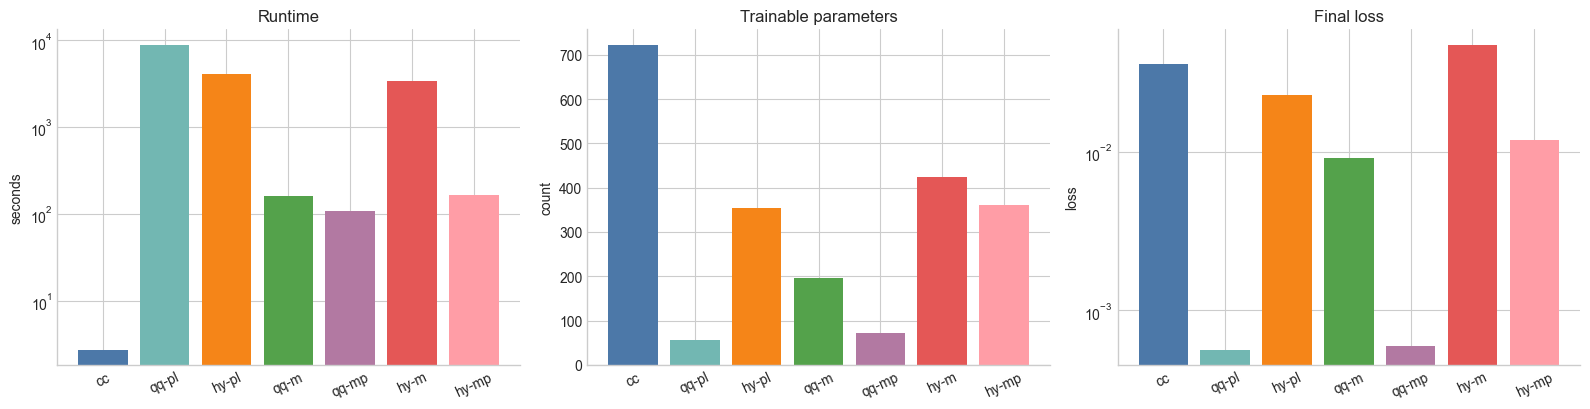

In [7]:
display_final_comparison(results)
